<a href="https://colab.research.google.com/github/lucianavaldovinosweiler-crypto/robot-arm-pid-simulation/blob/main/ArmSimulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robot Arm Control Simulation (PID Controller)

## What I built
A Python simulation of a one-joint robot arm driven by a motor. The arm starts hanging straight down and has to lift and hold itself at 90°, or straight out, against gravity. The simulation calculates the arm's position every millisecond, and a PID controller decides how hard the motor pushes.

- **P** pushes toward the target, harder the farther away the arm is.
- **I** builds up extra push the longer the arm stays below the target (fixes sagging from gravity).
- **D** acts as a brake based on how fast the arm is moving (stops the swinging).

## What I tested
1. **P only vs. full PID:** P alone left the arm swinging and sagging below 90° (at about 76°).
2. **Tuning Ki:** tested Ki = 5 to 30 with Kp = 20, Kd = 4.
3. **Tuning Kd:** tested Kd = 1 to 6 with Kp = 20, Ki = 15.
4. **Sensor noise:** tested noise levels from 0 to 0.5°, and used 0.1° as the main realistic case for the Kd test, to see how the controller handles imperfect sensor readings.

For each run, I measured final error, overshoot, settling time (time to stay within 2° of the target), and motor jitter (how shaky the motor command is).

## What I found
- **Ki:** Ki = 20 overshot by 3.2°. Lowering it to **Ki = 15 removed the overshoot and cut settling time from 1.26 s to 0.57 s**. Too low (Ki = 5–10) left the arm sagging below 90°.
- **Kd:** Below 4, the brake was too weak, so the arm overshot and dipped below 90°. Above 4, the brake was too strong, so the arm moved slower and ended above 90°. **Kd = 4 was the best** (no overshoot and settled in 0.57 s).
- **Sensor noise:** Just 0.1° of noise barely changed the arm's position, but motor jitter jumped from 0.05 to 16.7 (over 300x more). The controller reacts to the sensor's small random errors, and the D term amplifies them most.
- **Tradeoff:** With noise, jitter increased every time Kd went up (8.4 at Kd = 2 → 25.5 at Kd = 6). Choosing Kd is a tradeoff between smooth arm movement and a smooth, low-wear motor.

**Final settings:** Kp = 20, Ki = 15, Kd = 4 (or Kd = 3 if reducing motor shaking matters more).

## What I'd do next
- Filter the sensor signal to reduce motor jitter.
- Add a second arm link (like an elbow) to model a more realistic robot arm.
- Add a motor strength limit to see how it affects performance.

## Tools
Python, NumPy, pandas, Matplotlib (Google Colab). I used Claude (AI) to help write the code and learn PID control, then ran the experiments, tuned the controller, and analyzed the results.

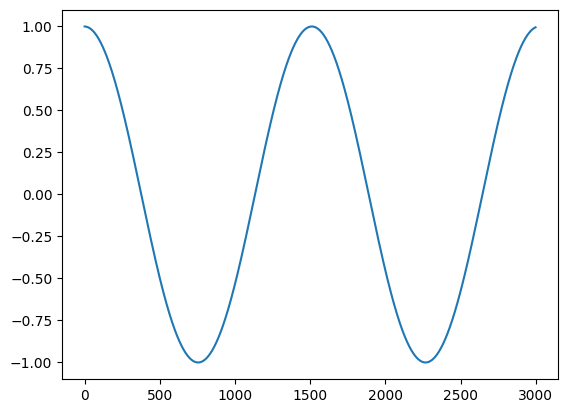

In [5]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81     # gravity
L = 0.5      # pendulum length (meters)
dt = 0.001   # time step = 1 millisecond

angle = 1.0  # starting angle (radians, about 57°)
speed = 0.0  # starts still

angles = []
for step in range(3000):                 # 3000 steps = 3 seconds
    accel = -(g / L) * np.sin(angle)     # gravity pulls it back toward the bottom
    speed = speed + accel * dt           # update speed
    angle = angle + speed * dt           # update position
    angles.append(angle)

plt.plot(angles)
plt.show()

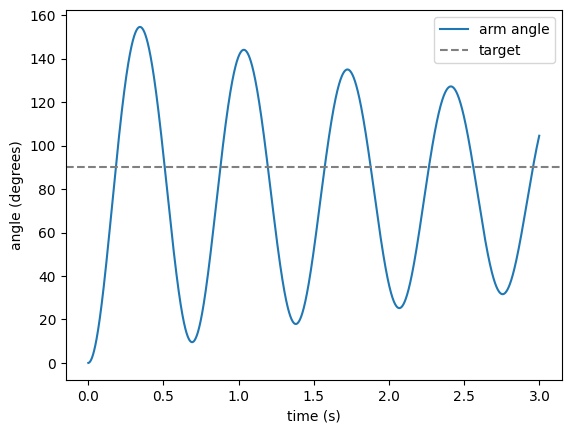

In [6]:
m = 1.0          # mass at the end of the arm (kg)
b = 0.1          # friction in the joint
target = 90      # goal: hold the arm straight out sideways (degrees)

Kp = 20          # how hard to push per unit of error

angle = 0.0      # start hanging straight down
speed = 0.0
times, angles = [], []

for step in range(3000):
    error = np.radians(target) - angle            # how far off are we?
    torque = Kp * error                           # P: push harder when farther off
    gravity = m * g * L * np.sin(angle)           # gravity pulling the arm down
    accel = (torque - gravity - b * speed) / (m * L**2)
    speed = speed + accel * dt
    angle = angle + speed * dt
    times.append(step * dt)
    angles.append(np.degrees(angle))

plt.plot(times, angles, label="arm angle")
plt.axhline(target, linestyle="--", color="gray", label="target")
plt.xlabel("time (s)"); plt.ylabel("angle (degrees)"); plt.legend()
plt.show()

In [16]:
#Measuring where arm is centered (middle point between low and high points)
times, angles, torques = simulate(Kp=20, Ki=0, Kd=0, seconds=10)

last = angles[times > 8]      # only the last 2 seconds

print("highest:", round(last.max(), 1))
print("lowest:", round(last.min(), 1))
print("middle:", round((last.max() + last.min()) / 2, 1))

highest: 90.8
lowest: 61.1
middle: 76.0


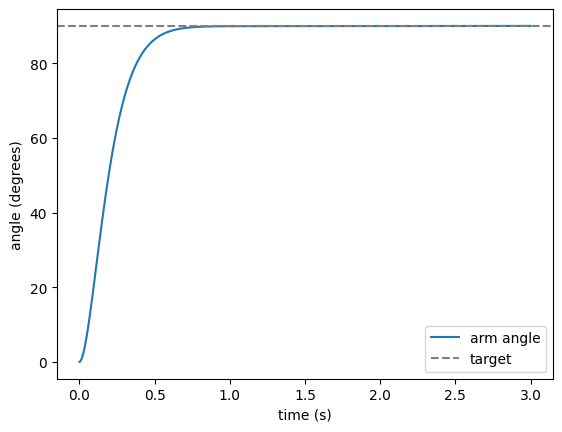

final angle: 89.98233813565771


In [7]:
Kp, Ki, Kd = 20, 15, 4

angle, speed = 0.0, 0.0
integral, prev_error = 0.0, 0.0
times, angles = [], []

for step in range(3000):
    error = np.radians(target) - angle
    integral = integral + error * dt                              # I: error added up over time
    derivative = (error - prev_error) / dt if step > 0 else 0.0  # D: how fast the error is changing
    prev_error = error

    torque = Kp * error + Ki * integral + Kd * derivative
    gravity = m * g * L * np.sin(angle)
    accel = (torque - gravity - b * speed) / (m * L**2)
    speed = speed + accel * dt
    angle = angle + speed * dt
    times.append(step * dt)
    angles.append(np.degrees(angle))

plt.plot(times, angles, label="arm angle")
plt.axhline(target, linestyle="--", color="gray", label="target")
plt.xlabel("time (s)"); plt.ylabel("angle (degrees)"); plt.legend()
plt.show()
print("final angle:", angles[-1])

In [9]:
import pandas as pd

def simulate(Kp, Ki, Kd, seconds=3):
    angle, speed = 0.0, 0.0
    integral, prev_error = 0.0, 0.0
    times, angles = [], []
    for step in range(int(seconds / dt)):
        error = np.radians(target) - angle
        integral = integral + error * dt
        derivative = (error - prev_error) / dt if step > 0 else 0.0
        prev_error = error
        torque = Kp * error + Ki * integral + Kd * derivative
        gravity = m * g * L * np.sin(angle)
        accel = (torque - gravity - b * speed) / (m * L**2)
        speed = speed + accel * dt
        angle = angle + speed * dt
        times.append(step * dt)
        angles.append(np.degrees(angle))
    return np.array(times), np.array(angles)


def score(times, angles):
    error = target - angles
    outside = np.where(abs(error) > 2)[0]
    return {
        "final_error": abs(error[-1]),
        "overshoot": max(0, angles.max() - target),
        "settling_time": times[outside[-1]] if len(outside) > 0 else 0,
    }

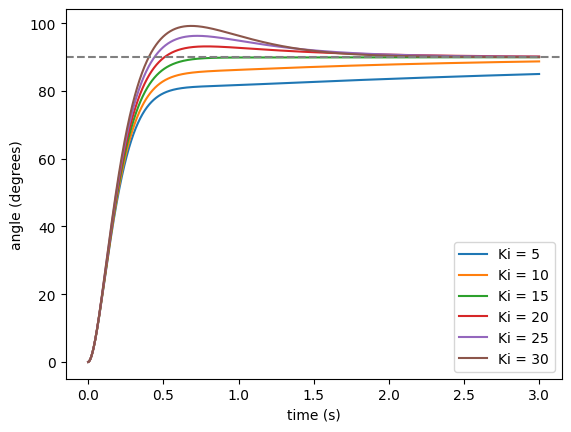

   Ki  final_error  overshoot  settling_time
0   5         4.97       0.00           3.00
1  10         1.25       0.00           2.16
2  15         0.02       0.00           0.57
3  20         0.19       3.18           1.26
4  25         0.11       6.30           1.50
5  30         0.02       9.23           1.48


In [11]:
results = []

for Ki in [5, 10, 15, 20, 25, 30]:
    times, angles = simulate(Kp=20, Ki=Ki, Kd=4)
    results.append({"Ki": Ki, **score(times, angles)})
    plt.plot(times, angles, label=f"Ki = {Ki}")

plt.axhline(target, linestyle="--", color="gray")
plt.xlabel("time (s)"); plt.ylabel("angle (degrees)"); plt.legend()
plt.show()

df = pd.DataFrame(results).round(2)
print(df)
df.to_csv("ki_sweep.csv", index=False)

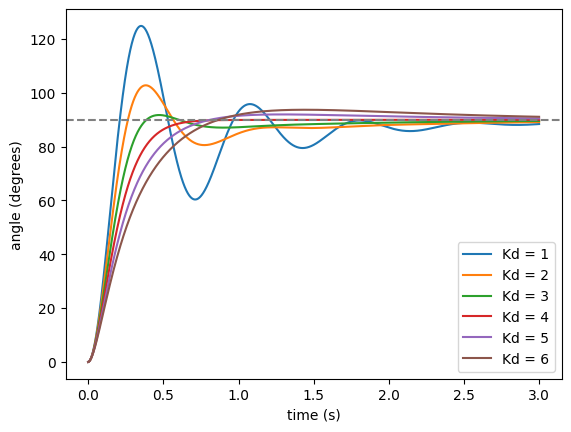

   Kd  final_error  overshoot  settling_time
0   1         1.61      34.84           2.38
1   2         0.88      12.78           1.96
2   3         0.46       1.74           1.29
3   4         0.02       0.00           0.57
4   5         0.48       1.96           0.69
5   6         1.08       3.70           2.39


In [12]:
results = []

for Kd in [1, 2, 3, 4, 5, 6]:
    times, angles = simulate(Kp=20, Ki=15, Kd=Kd)
    results.append({"Kd": Kd, **score(times, angles)})
    plt.plot(times, angles, label=f"Kd = {Kd}")

plt.axhline(target, linestyle="--", color="gray")
plt.xlabel("time (s)"); plt.ylabel("angle (degrees)"); plt.legend()
plt.show()

df = pd.DataFrame(results).round(2)
print(df)
df.to_csv("kd_sweep.csv", index=False)

In [13]:
def simulate(Kp, Ki, Kd, noise=0.0, seconds=3):                  # NEW: noise setting
    angle, speed = 0.0, 0.0
    integral, prev_error = 0.0, 0.0
    times, angles, torques = [], [], []                            # NEW: torques list
    for step in range(int(seconds / dt)):
        measured = angle + np.radians(np.random.normal(0, noise))  # NEW: sensor reading
        error = np.radians(target) - measured                     # NEW: uses measured
        integral = integral + error * dt
        derivative = (error - prev_error) / dt if step > 0 else 0.0
        prev_error = error
        torque = Kp * error + Ki * integral + Kd * derivative
        gravity = m * g * L * np.sin(angle)
        accel = (torque - gravity - b * speed) / (m * L**2)
        speed = speed + accel * dt
        angle = angle + speed * dt
        times.append(step * dt)
        angles.append(np.degrees(angle))
        torques.append(torque)                                     # NEW: record motor push
    return np.array(times), np.array(angles), np.array(torques)   # NEW: returns torques too


def score(times, angles, torques):                                 # NEW: takes torques
    error = target - angles
    outside = np.where(abs(error) > 2)[0]
    return {
        "final_error": abs(error[-1]),
        "overshoot": max(0, angles.max() - target),
        "settling_time": times[outside[-1]] if len(outside) > 0 else 0,
        "jitter": np.std(np.diff(torques)),                        # NEW: motor shakiness
    }

   noise  final_error  overshoot  settling_time  jitter
0   0.00         0.02       0.00           0.57    0.05
1   0.05         0.01       0.00           0.57    8.66
2   0.10         0.01       0.00           0.57   16.72
3   0.20         0.03       0.02           0.57   34.79
4   0.50         0.12       0.06           0.57   84.83


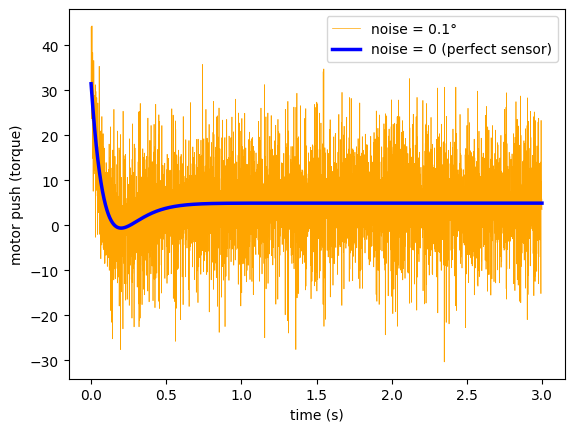

In [14]:
np.random.seed(0)
results = []

for noise in [0, 0.05, 0.1, 0.2, 0.5]:
    times, angles, torques = simulate(Kp=20, Ki=15, Kd=4, noise=noise)
    results.append({"noise": noise, **score(times, angles, torques)})

df = pd.DataFrame(results).round(2)
print(df)
df.to_csv("noise_sweep.csv", index=False)

# Noisy sensor first (thin, in the background)
times, angles, torques = simulate(Kp=20, Ki=15, Kd=4, noise=0.1)
plt.plot(times, torques, linewidth=0.5, color="orange", label="noise = 0.1°")

# Perfect sensor on top (thick, so you can see it)
times, angles, torques = simulate(Kp=20, Ki=15, Kd=4, noise=0)
plt.plot(times, torques, linewidth=2.5, color="blue", label="noise = 0 (perfect sensor)")

plt.xlabel("time (s)"); plt.ylabel("motor push (torque)"); plt.legend()
plt.show()

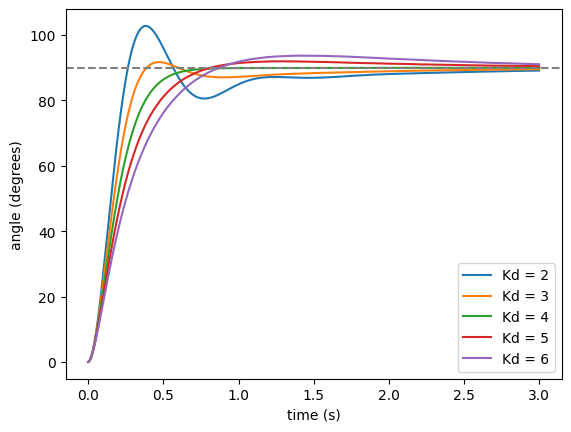

   noise  final_error  overshoot  settling_time  jitter
0    0.5         0.87      12.78           1.96    8.35
1    0.5         0.45       1.72           1.29   12.97
2    0.5         0.01       0.00           0.57   16.72
3    0.5         0.47       1.96           0.69   21.78
4    0.5         1.06       3.70           2.39   25.53


In [15]:
np.random.seed(0)
results = []

for Kd in [2, 3, 4, 5, 6]:
    times, angles, torques = simulate(Kp=20, Ki=15, Kd=Kd, noise=0.1)
    results.append({"noise": noise, **score(times, angles, torques)})
    plt.plot(times, angles, label=f"Kd = {Kd}")

plt.axhline(target, linestyle="--", color="gray")
plt.xlabel("time (s)"); plt.ylabel("angle (degrees)"); plt.legend()
plt.show()

df = pd.DataFrame(results).round(2)
print(df)
df.to_csv("kd_noise_sweep.csv", index=False)